# Part 2 — Benchmarking

Tests multiple Vision LLMs on the corrupted dataset built in Part 1.

**Task**: given a document image + a question, predict whether the question is `ANSWERABLE` or `UNANSWERABLE`.

**Evaluation set**: for every entry in `corrupted_dataset.json` we produce two samples on the **same document**:
- the *original* question → ground truth `ANSWERABLE`
- the *corrupted* question → ground truth `UNANSWERABLE`

This gives a perfectly balanced binary classification benchmark where the only difference is the question text.

In [1]:
CONFIG = {
    # ---- input (output of Part 1) ----
    "corrupted_dataset_path": "data/corrupted_dataset.json",
    # ---- models to benchmark (NOT the judge used in Part 1) ----
    "benchmark_models": [
        "llava-hf/llava-v1.6-mistral-7b-hf",
        "google/gemma-3-4b-it",
        "google/gemma-3-12b-it",
    ],
    # ---- output ----
    "results_path": "data/benchmark_results.json",
    "figures_dir": "data/figures",
    # ---- misc ----
    "seed": 42,
}

## Experimental setup

| Aspect | Choice |
|---|---|
| **Task** | Binary classification — given a document image + question, predict `ANSWERABLE` or `UNANSWERABLE` |
| **Eval set** | Each of the 59 verified-unanswerable samples from Part 1 contributes two test samples on the **same document**: the original question (ground truth `ANSWERABLE`) and the corrupted question (ground truth `UNANSWERABLE`). This yields a perfectly balanced 118-sample benchmark. |
| **Models** | Gemma-3-4b-it · Gemma-3-12b-it · Phi-4-multimodal-instruct |
| **Inference** | Zero-shot; single-word forced output (`ANSWERABLE` / `UNANSWERABLE`); `bfloat16`; `device_map="auto"` |
| **Metrics** | Accuracy, Precision, Recall, F1 — all with **`UNANSWERABLE` as the positive class** (the harder, more important class to detect) |
| **Memory** | Each model is explicitly unloaded (`gc.collect()` + `torch.cuda.empty_cache()`) before the next one is loaded |

In [2]:
import gc
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from tqdm import tqdm
import torch
from PIL import Image
from transformers import AutoProcessor

# Consistent with Part 1 — DocVQA images can be high-res
Image.MAX_IMAGE_PIXELS = None

try:
    from transformers import AutoModelForImageTextToText
    _ModelClass = AutoModelForImageTextToText
except ImportError:
    from transformers import AutoModelForCausalLM
    _ModelClass = AutoModelForCausalLM

random.seed(CONFIG["seed"])
Path(CONFIG["figures_dir"]).mkdir(parents=True, exist_ok=True)

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  {p.total_memory / 1e9:.1f} GB")

/davinci-1/home/abuonfiglio/MasterPoliTO/GenAI/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available : True
  GPU 0: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 1: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 2: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 3: NVIDIA A100-SXM4-40GB  42.4 GB


## Build evaluation set

In [3]:
with open(CONFIG["corrupted_dataset_path"]) as f:
    corrupted_data = json.load(f)

eval_samples = []
for item in corrupted_data:
    # ANSWERABLE: original question on the same document
    eval_samples.append({
        "image_path":     item["image_path"],
        "question":       item["original_question"],
        "label":          "ANSWERABLE",
        "corruption_type": item["corruption_type"],
        "idx":            item["idx"],
    })
    # UNANSWERABLE: corrupted question on the same document
    eval_samples.append({
        "image_path":     item["image_path"],
        "question":       item["corrupted_question"],
        "label":          "UNANSWERABLE",
        "corruption_type": item["corruption_type"],
        "idx":            item["idx"],
    })

random.shuffle(eval_samples)
ground_truth = [s["label"] for s in eval_samples]

print(f"Eval set: {len(eval_samples)} samples")
print(f"  ANSWERABLE   : {ground_truth.count('ANSWERABLE')}")
print(f"  UNANSWERABLE : {ground_truth.count('UNANSWERABLE')}")

Eval set: 118 samples
  ANSWERABLE   : 59
  UNANSWERABLE : 59


## Benchmark loop

Each model is loaded, run on all eval samples, then **unloaded** before the next one to free GPU memory.

In [4]:
INFERENCE_PROMPT = (
    "Look at this document image carefully.\n"
    "Can the following question be answered based on the content visible in the document?\n\n"
    "Question: {question}\n\n"
    "Answer with one word only: ANSWERABLE or UNANSWERABLE"
)


def load_model(model_name):
    from transformers import AutoModelForCausalLM
    processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
    try:
        model = _ModelClass.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.bfloat16,
            trust_remote_code=True,
        )
    except ValueError:
        # Some models (e.g. Phi-4-multimodal) register only with AutoModelForCausalLM,
        # not with AutoModelForImageTextToText.
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.bfloat16,
            trust_remote_code=True,
        )
    model.eval()
    return model, processor


def unload_model(model, processor):
    del model, processor
    gc.collect()
    torch.cuda.empty_cache()


def predict(model, processor, pil_image, question):
    messages = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": INFERENCE_PROMPT.format(question=question)},
    ]}]

    # Some processors (e.g. Phi-4) expose apply_chat_template on the tokenizer sub-object
    apply_fn = getattr(processor, "apply_chat_template", None) \
               or processor.tokenizer.apply_chat_template
    # tokenize=False is required — without it, some processors return token IDs, not a string
    text = apply_fn(messages, add_generation_prompt=True, tokenize=False)

    # For device_map="auto" models the embedding layer is on the first GPU
    device = next(model.parameters()).device
    inputs = processor(text=text, images=[pil_image], return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=10, do_sample=False)

    input_len = inputs["input_ids"].shape[1]
    decode_fn = getattr(processor, "decode", None) or processor.tokenizer.decode
    response = decode_fn(out[0][input_len:], skip_special_tokens=True).strip().upper()
    return "UNANSWERABLE" if "UNANSWERABLE" in response else "ANSWERABLE"

In [5]:
all_predictions = {}   # model_name -> list of predictions

for model_name in CONFIG["benchmark_models"]:
    short = model_name.split("/")[-1]
    print(f"\n{'='*60}\nBenchmarking: {model_name}\n{'='*60}")

    model, processor = load_model(model_name)
    predictions = []

    for sample in tqdm(eval_samples, desc=short):
        img = Image.open(sample["image_path"]).convert("RGB")
        pred = predict(model, processor, img, sample["question"])
        predictions.append(pred)

    all_predictions[model_name] = predictions
    unload_model(model, processor)

    # Checkpoint after each model in case of crash
    with open(CONFIG["results_path"], "w") as f:
        json.dump({"eval_samples": eval_samples, "predictions": all_predictions}, f, indent=2)
    print(f"  Checkpoint saved → {CONFIG['results_path']}")


Benchmarking: llava-hf/llava-v1.6-mistral-7b-hf


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 687/687 [00:30<00:00, 22.34it/s] 
/davinci-1/home/abuonfiglio/MasterPoliTO/GenAI/.venv/lib/python3.10/site-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(
llava-v1.6-mistral-7b-hf: 100%|██████████| 118/118 [00:54<00:00,  2.17it/s]


  Checkpoint saved → data/benchmark_results.json

Benchmarking: google/gemma-3-4b-it


gemma-3-4b-it: 100%|██████████| 118/118 [00:39<00:00,  3.01it/s]


  Checkpoint saved → data/benchmark_results.json

Benchmarking: google/gemma-3-12b-it


gemma-3-12b-it: 100%|██████████| 118/118 [00:50<00:00,  2.32it/s]


  Checkpoint saved → data/benchmark_results.json


## Metrics

In [6]:
rows = []
for model_name, preds in all_predictions.items():
    acc = accuracy_score(ground_truth, preds)
    p, r, f1, _ = precision_recall_fscore_support(
        ground_truth, preds,
        labels=["UNANSWERABLE"], pos_label="UNANSWERABLE", average="binary",
    )
    rows.append({
        "model":     model_name.split("/")[-1],
        "accuracy":  acc,
        "precision": p,
        "recall":    r,
        "f1":        f1,
    })

df_metrics = pd.DataFrame(rows).set_index("model")
print("=== Results (UNANSWERABLE as positive class) ===")
print(df_metrics.round(3).to_string())

=== Results (UNANSWERABLE as positive class) ===
                          accuracy  precision  recall     f1
model                                                       
llava-v1.6-mistral-7b-hf     0.559      0.551   0.644  0.594
gemma-3-4b-it                0.542      0.544   0.525  0.534
gemma-3-12b-it               0.525      0.519   0.695  0.594


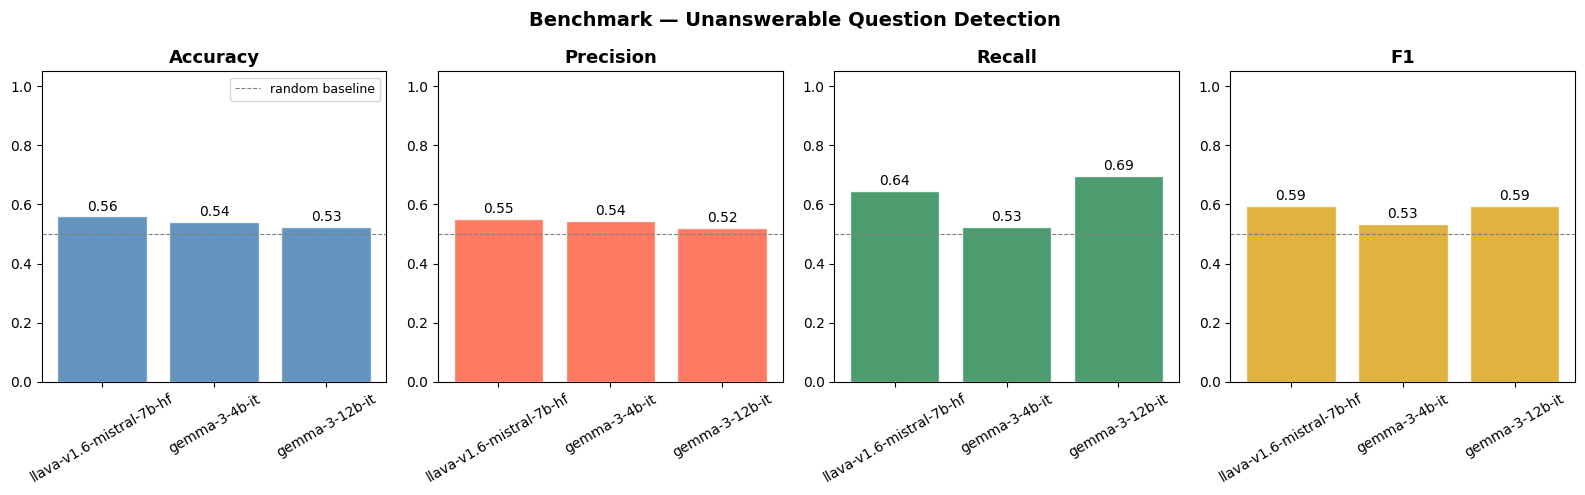

Saved → data/figures/overall_metrics.png


In [7]:
# --- Bar chart: overall metrics per model ---
metrics = ["accuracy", "precision", "recall", "f1"]
colors  = ["steelblue", "tomato", "seagreen", "goldenrod"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, metric, color in zip(axes, metrics, colors):
    vals = df_metrics[metric]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(metric.capitalize(), fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="random baseline")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10)

axes[0].legend(fontsize=9)
plt.suptitle("Benchmark — Unanswerable Question Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
out = Path(CONFIG["figures_dir"]) / "overall_metrics.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Per-corruption-type recall

Which corruption type is hardest to detect? For each model and each corruption type we compute the **recall on UNANSWERABLE** samples (= what fraction of corrupted questions does the model correctly flag as unanswerable).

In [8]:
ctypes       = ["nlp_entity", "element", "layout"]
model_labels = [m.split("/")[-1] for m in CONFIG["benchmark_models"]]

recall_matrix = np.zeros((len(model_labels), len(ctypes)))

for j, ctype in enumerate(ctypes):
    # indices of UNANSWERABLE samples of this corruption type
    idxs = [i for i, s in enumerate(eval_samples)
            if s["corruption_type"] == ctype and s["label"] == "UNANSWERABLE"]
    for i, model_name in enumerate(CONFIG["benchmark_models"]):
        preds = all_predictions[model_name]
        preds_type = [preds[k] for k in idxs]
        recall_matrix[i, j] = (
            sum(p == "UNANSWERABLE" for p in preds_type) / len(preds_type)
            if preds_type else 0.0
        )

print("=== UNANSWERABLE recall per corruption type ===")
df_recall = pd.DataFrame(recall_matrix, index=model_labels, columns=ctypes)
print(df_recall.round(3).to_string())

=== UNANSWERABLE recall per corruption type ===
                          nlp_entity  element  layout
llava-v1.6-mistral-7b-hf       0.689    0.333   0.545
gemma-3-4b-it                  0.667    0.000   0.091
gemma-3-12b-it                 0.822    0.000   0.364


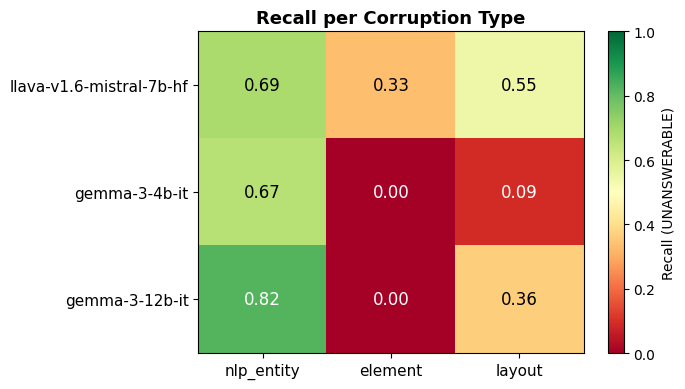

Saved → data/figures/per_type_recall.png


In [9]:
# --- Heatmap ---
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(recall_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ctypes)))
ax.set_xticklabels(ctypes, fontsize=11)
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels, fontsize=11)
plt.colorbar(im, ax=ax, label="Recall (UNANSWERABLE)")
for i in range(len(model_labels)):
    for j in range(len(ctypes)):
        ax.text(j, i, f"{recall_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=12,
                color="black" if 0.3 < recall_matrix[i, j] < 0.8 else "white")
ax.set_title("Recall per Corruption Type", fontsize=13, fontweight="bold")
plt.tight_layout()
out = Path(CONFIG["figures_dir"]) / "per_type_recall.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Confusion matrices

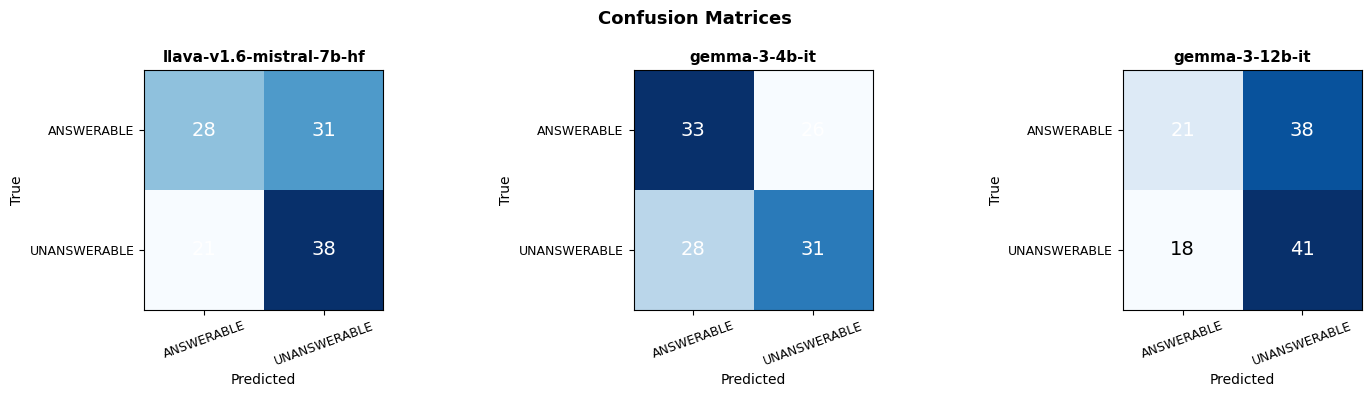

Saved → data/figures/confusion_matrices.png


In [10]:
labels = ["ANSWERABLE", "UNANSWERABLE"]
n_models = len(CONFIG["benchmark_models"])
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, model_name in zip(axes, CONFIG["benchmark_models"]):
    preds = all_predictions[model_name]
    cm = confusion_matrix(ground_truth, preds, labels=labels)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, rotation=20, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(model_name.split("/")[-1], fontsize=11, fontweight="bold")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
out = Path(CONFIG["figures_dir"]) / "confusion_matrices.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Critical analysis

After examining the quantitative results above, the key questions to address are:

**1. Overall discrimination ability**  
Compare each model's accuracy and F1 against the 0.5 random-baseline line. A model that collapses to "always ANSWERABLE" would achieve 50 % accuracy but 0 % recall on UNANSWERABLE — the plots reveal whether any model falls into this failure mode.

**2. Per-corruption-type difficulty**  
The heatmap shows which corruption type is hardest to detect:
- *NLP-entity* corruptions (e.g. city name swap) leave the document structure intact; models that rely on visual layout cues may miss these.
- *Element* corruptions (table → figure) require understanding document-element vocabulary; expected to be easier for models trained on DocVQA-style tasks.
- *Layout* corruptions (top → bottom) require spatial reasoning; typically the hardest category.

**3. Failure modes**  
Low recall on UNANSWERABLE with high precision indicates a model that is "over-trusting" — it answers most questions rather than admitting they are unanswerable. This is the expected failure mode for instruction-tuned VLMs trained to be helpful. The confusion matrix diagonal reveals the dominant error direction.

**4. Size vs. capability trade-off**  
Comparing Gemma-3-4b vs. Gemma-3-12b isolates the effect of model scale within the same architecture family. A large gap suggests the task is parameter-sensitive; a small gap suggests it is primarily a task-format issue addressable by prompt engineering (→ Part 3).